# Experiment 4 — Transfer Learning Using Pre-trained Vision Models
**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072



## Step 1 — Install required packages


In [1]:
!pip -q install kagglehub tensorflow matplotlib scikit-learn

## Step 2 — Download the Kaggle dataset


In [2]:
import kagglehub
from pathlib import Path

# Download the Cat vs Dog dataset from Kaggle.
# If Kaggle asks for authentication, follow the displayed instructions.
downloaded_path = kagglehub.dataset_download("tongpython/cat-and-dog")

DATASET_ROOT = Path(downloaded_path)

print("Dataset downloaded to:")
print(DATASET_ROOT)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset downloaded to:
/kaggle/input/cat-and-dog


## Step 3 — Discover the image folders automatically



In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_folders = []

for folder in DATASET_ROOT.rglob("*"):
    if folder.is_dir():
        count = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        )
        if count:
            image_folders.append((folder, count))

print("Image-containing folders:")
for folder, count in image_folders:
    print(f"{folder} -> {count} images")

Image-containing folders:
/kaggle/input/cat-and-dog/training_set/training_set/dogs -> 4005 images
/kaggle/input/cat-and-dog/training_set/training_set/cats -> 4000 images
/kaggle/input/cat-and-dog/test_set/test_set/dogs -> 1012 images
/kaggle/input/cat-and-dog/test_set/test_set/cats -> 1011 images


## Step 4 — Identify Cat and Dog folders



In [4]:
def find_folder(keyword):
    matches = [
        folder for folder, count in image_folders
        if keyword.lower() in folder.name.lower()
    ]
    if not matches:
        raise FileNotFoundError(f"No folder found for: {keyword}")
    return matches[0]

CAT_DIR = find_folder("cat")
DOG_DIR = find_folder("dog")

print("Cat folder:", CAT_DIR)
print("Dog folder:", DOG_DIR)

Cat folder: /kaggle/input/cat-and-dog/training_set/training_set/cats
Dog folder: /kaggle/input/cat-and-dog/training_set/training_set/dogs


## Step 5 — Create image paths and labels



In [5]:
import pandas as pd

#Cats are assigned label `0` and dogs are assigned label `1`.

rows = []

for class_id, (class_name, class_dir) in enumerate([
    ("Cat", CAT_DIR),
    ("Dog", DOG_DIR)
]):
    for file in class_dir.iterdir():
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            rows.append({
                "path": str(file),
                "label": class_id,
                "class_name": class_name
            })

images_df = pd.DataFrame(rows)

print("Total images:", len(images_df))
print("\nClass distribution:")
print(images_df["class_name"].value_counts())

Total images: 8005

Class distribution:
class_name
Dog    4005
Cat    4000
Name: count, dtype: int64


## Step 6 — Split into training, validation and test sets



In [6]:
from sklearn.model_selection import train_test_split

train_df, remaining_df = train_test_split(
    images_df,
    test_size=0.30,
    random_state=24,
    stratify=images_df["label"]
)

validation_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50,
    random_state=24,
    stratify=remaining_df["label"]
)

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

Training: 5603
Validation: 1201
Testing: 1201


## Step 7 — Build TensorFlow datasets

In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def decode_and_resize(path, label):
    raw = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_tf_dataset(frame, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame["path"].to_numpy(), frame["label"].to_numpy())
    )
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(frame),
            seed=24,
            reshuffle_each_iteration=True
        )
    return (
        dataset
        .map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

train_ds = make_tf_dataset(train_df, shuffle=True)
validation_ds = make_tf_dataset(validation_df)
test_ds = make_tf_dataset(test_df)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


## Step 8 — Verify sample images

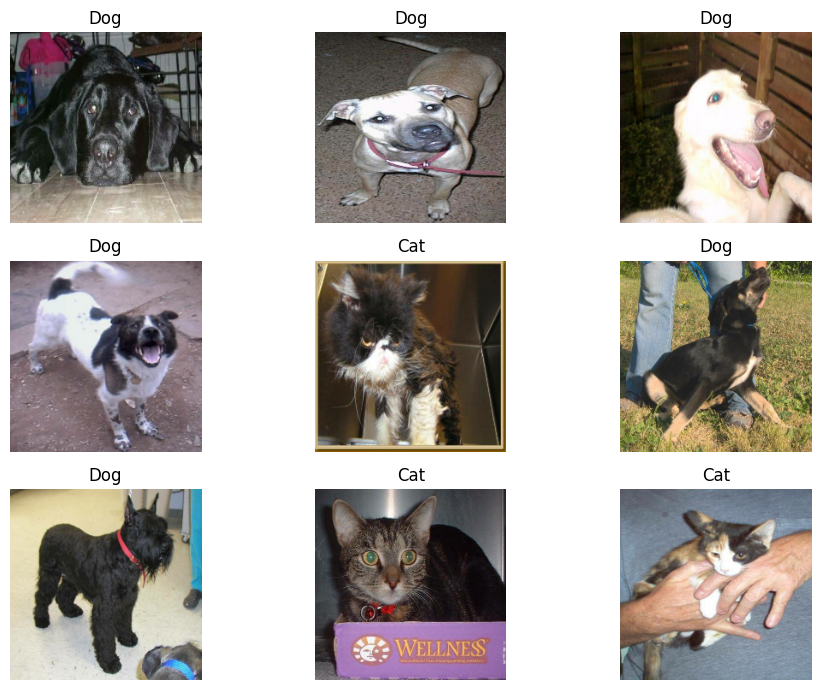

In [8]:
import matplotlib.pyplot as plt

batch_images, batch_labels = next(iter(train_ds))

plt.figure(figsize=(10, 7))

for index in range(min(9, len(batch_images))):
    plt.subplot(3, 3, index + 1)
    plt.imshow(batch_images[index].numpy().astype("uint8"))
    plt.title(["Cat", "Dog"][int(batch_labels[index].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 9 — Load pre-trained ResNet-50


In [9]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

feature_extractor = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

feature_extractor.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = feature_extractor(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(2, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      4,098 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 10 — Train the transfer-learning model

In [10]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 65s 251ms/step - accuracy: 0.9573 - loss: 0.1055 - val_accuracy: 0.9842 - val_loss: 0.0351
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.9882 - loss: 0.0344 - val_accuracy: 0.9933 - val_loss: 0.0230
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9911 - loss: 0.0261 - val_accuracy: 0.9908 - val_loss: 0.0326
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9939 - loss: 0.0188 - val_accuracy: 0.9892 - val_loss: 0.0280
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.9920 - loss: 0.0205 - val_accuracy: 0.9917 - val_loss: 0.0219
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9957 - loss: 0.0136 - val_accuracy: 0.9850 - val_loss: 0.0476
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.9957 - loss: 0.0140 - val_accuracy: 0.9933 - val_loss: 0.0206
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.9977 - loss: 0.

## Step 11 — Evaluate on the test set

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9867 - loss: 0.0395
Test loss: 0.0395
Test accuracy: 98.67%


## Step 12 — Accuracy vs Epoch

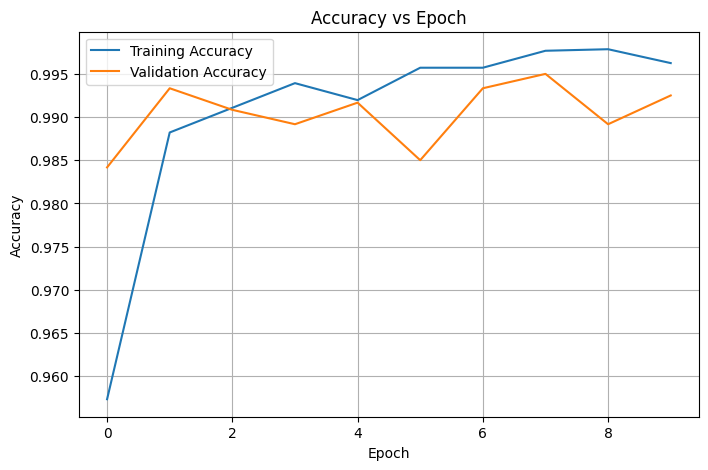

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Step 13 — Loss vs Epoch

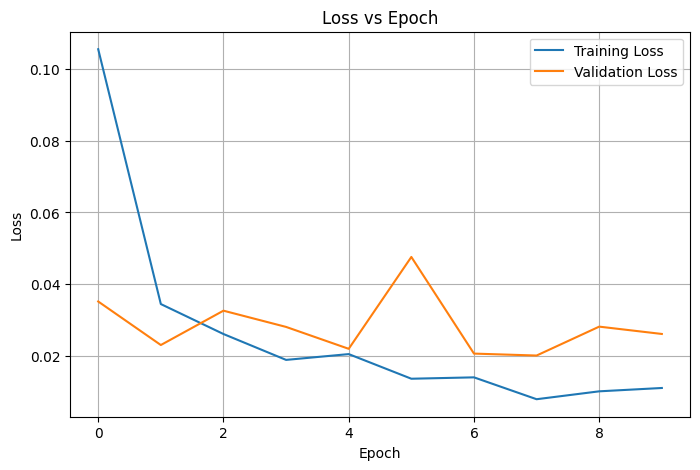

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Step 14 — Classification report and confusion matrix

              precision    recall  f1-score   support

         Cat       0.99      0.98      0.99       600
         Dog       0.98      0.99      0.99       601

    accuracy                           0.99      1201
   macro avg       0.99      0.99      0.99      1201
weighted avg       0.99      0.99      0.99      1201



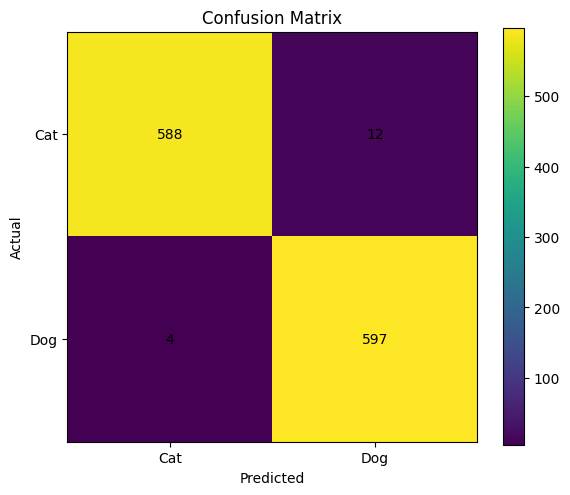

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

true_labels = []
predicted_labels = []

for batch_x, batch_y in test_ds:
    probabilities = model.predict(batch_x, verbose=0)
    true_labels.extend(batch_y.numpy().astype(int))
    predicted_labels.extend(np.argmax(probabilities, axis=1))

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["Cat", "Dog"],
    zero_division=0
))

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## Step 15 — fine-tuning



In [15]:
# fine-tune only the final part of ResNet-50

feature_extractor.trainable = True

for layer in feature_extractor.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=5
)

fine_loss, fine_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Fine-tuned test accuracy: {fine_accuracy * 100:.2f}%")

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 200ms/step - accuracy: 0.9925 - loss: 0.0213 - val_accuracy: 0.9892 - val_loss: 0.0325
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.9963 - loss: 0.0099 - val_accuracy: 0.9883 - val_loss: 0.0290
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9883 - val_loss: 0.0321
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 137ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9875 - val_loss: 0.0316
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accuracy: 0.9925 - val_loss: 0.0235
Fine-tuned test accuracy: 98.92%


## Step 16 — Hugging Face pre-trained vision model


In [16]:
!pip -q install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.5 MB/s eta 0:00:00


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

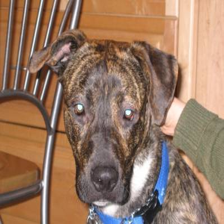

Hugging Face predictions:
{'label': 'Staffordshire bullterrier, Staffordshire bull terrier', 'score': 0.4806719422340393}
{'label': 'American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier', 'score': 0.46779364347457886}
{'label': 'bull mastiff', 'score': 0.035211022943258286}
{'label': 'Great Dane', 'score': 0.00540877366438508}
{'label': 'boxer', 'score': 0.0026393465232104063}


In [17]:
from transformers import pipeline
from PIL import Image

hf_model = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

sample_file = test_df.iloc[0]["path"]
sample = Image.open(sample_file).convert("RGB")

display(sample.resize((224, 224)))

results = hf_model(sample)

print("Hugging Face predictions:")
for result in results[:5]:
    print(result)

## Step 17 — Final experiment results

Use these actual values in your lab record instead of using example numbers.

In [18]:
print("========== FINAL RESULTS ==========")
print(f"Training images   : {len(train_df)}")
print(f"Validation images : {len(validation_df)}")
print(f"Testing images    : {len(test_df)}")
print(f"Best training accuracy   : {max(history.history['accuracy']) * 100:.2f}%")
print(f"Best validation accuracy : {max(history.history['val_accuracy']) * 100:.2f}%")
print(f"Test accuracy            : {test_accuracy * 100:.2f}%")

========== FINAL RESULTS ==========
Training images   : 5603
Validation images : 1201
Testing images    : 1201
Best training accuracy   : 99.79%
Best validation accuracy : 99.50%
Test accuracy            : 98.67%


## Step 18 — Observation

The model uses transfer learning from a ResNet-50 network pre-trained on ImageNet. The original classification head is replaced with a new two-class classifier, while the feature-extraction layers are initially frozen. The training and validation graphs show how the model learns across epochs, and the test accuracy provides the final evaluation on unseen images. Fine-tuning can be used after the initial training stage to allow selected deeper layers to adapt to the target dataset.

## Step 19 — Save the trained model

In [19]:
model.save("/content/resnet50_transfer_learning_cat_dog.keras")
print("Saved model successfully.")

Saved model successfully.
